# DS50 Face Recognition System - Basic Benchmark Notebook

This notebook provides a comprehensive testing and benchmarking framework for the DS50 car face authentication system.

## Overview

The notebook performs the following steps:
1. **Setup and Initialization** - Configure paths and initialize face recognition components
2. **Database Building** - Process reference images and create embedding database
3. **Benchmarking** - Test the system on a test dataset
4. **Results Analysis** - Display performance metrics with visualizations

## Requirements

- All required models must be present in the `models/` directory
- Reference images should be in `data/references/`
- Test images should be organized in `data/test/[identity]/` folders

In [1]:
import os
import sys
import cv2
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Dynamically set path to include project root and src/
try:
    # Get the notebook directory (notebooks folder)
    notebook_dir = os.path.dirname(os.path.abspath("benchmark.ipynb"))
    # Go up one level to reach project root
    project_root = os.path.dirname(notebook_dir)
    
    if project_root not in sys.path:
        sys.path.insert(0, project_root)
        print(f"✔ Added project root to sys.path: {project_root}")

except Exception as e:
    print(f"❌ Error setting up paths: {e}")
    sys.exit(1)

# Change working directory to project root for proper relative path resolution
os.chdir(project_root)
print(f"✔ Changed working directory to: {os.getcwd()}")

# Set matplotlib style for better plots
plt.style.use('default')
sns.set_palette("husl")

✔ Added project root to sys.path: c:\Users\leona\OneDrive - Universite De Technologie De Belfort-Montbeliard\Cours Sup\INFO\Semestre 4\DS50\ds50-car-face-auth
✔ Changed working directory to: c:\Users\leona\OneDrive - Universite De Technologie De Belfort-Montbeliard\Cours Sup\INFO\Semestre 4\DS50\ds50-car-face-auth


## Configuration and Component Initialization

Configure paths and initialize the face recognition system components.

In [2]:
# Import project modules after path setup
from src.embedding import FaceEmbedder
from src.recognition import FaceRecognizer
from src.detection import FaceDetector
from src.database import EmbeddingDatabase

# Configuration - Updated paths relative to project root
REF_DIR = os.path.join("data", "references")
TEST_ROOT = os.path.join("data", "test")
DB_PATH = os.path.join("data", "test_db.npz")
MODELS_PATH = "models"
RECOGNITION_THRESHOLD = 0.50

# Verify paths exist
print(f"📂 Reference directory: {REF_DIR} {'✅' if os.path.exists(REF_DIR) else '❌'}")
print(f"📂 Test directory: {TEST_ROOT} {'✅' if os.path.exists(TEST_ROOT) else '❌'}")
print(f"📂 Models directory: {MODELS_PATH} {'✅' if os.path.exists(MODELS_PATH) else '❌'}")

# Check required model files
required_models = ["det_10g.onnx", "w600k_r50.onnx"]
for model in required_models:
    model_path = os.path.join(MODELS_PATH, model)
    print(f"📄 {model}: {'✅' if os.path.exists(model_path) else '❌'}")

# --- Initialize components ---
try:
    detector = FaceDetector()
    embedder = FaceEmbedder()
    recognizer = FaceRecognizer(threshold=RECOGNITION_THRESHOLD)
    print("✅ Components initialized successfully")
except Exception as e:
    print(f"❌ Failed to initialize components: {e}")
    print("Make sure all required model files are in the models/ directory")
    raise

c:\Users\leona\OneDrive - Universite De Technologie De Belfort-Montbeliard\Cours Sup\INFO\Semestre 4\DS50\ds50-car-face-auth\venv\Lib\site-packages\albumentations\__init__.py:28: UserWarning: A new version of Albumentations is available: '2.0.8' (you have '2.0.5'). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


📂 Reference directory: data\references ✅
📂 Test directory: data\test ✅
📂 Models directory: models ✅
📄 det_10g.onnx: ✅
📄 w600k_r50.onnx: ✅
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
✅ Components initialized successfully


## Database Building

Build the reference embedding database from reference images.

In [3]:
def build_database(ref_dir, db_path):
    """Generate embeddings from reference images and save to disk."""
    database = EmbeddingDatabase(db_path)
    
    if not os.path.exists(ref_dir):
        print(f"❌ Reference directory not found: {ref_dir}")
        return False
        
    files = [f for f in os.listdir(ref_dir) if f.lower().endswith(('.jpg', '.png', '.jpeg'))]
    
    if not files:
        print(f"❌ No image files found in {ref_dir}")
        return False

    print(f"Found {len(files)} reference images: {files}")

    for file in tqdm(files, desc="Creating reference embeddings"):
        filepath = os.path.join(ref_dir, file)
        identity = os.path.splitext(file)[0]
        
        # Load image
        image = cv2.imread(filepath)
        if image is None:
            print(f"[WARN] Could not load image: {file}")
            continue
            
        # Detect faces
        bboxes, landmarks = detector.detect_faces(image)
        
        if bboxes is None or landmarks is None or len(bboxes) == 0:
            print(f"[WARN] No face found in {file}")
            continue
            
        # Use the first detected face
        landmark = landmarks[0]
        
        # Get embedding
        embedding = embedder.get_embedding(image, landmark, return_aligned=False)
        
        if embedding is not None:
            database.add_embedding(identity, embedding)
            print(f"✅ Added embedding for {identity}")
        else:
            print(f"[WARN] Failed to extract embedding from {file}")
    
    # Save database
    if database.save_to_file():
        print(f"\n✅ Reference database saved to {db_path}")
        return True
    else:
        print(f"\n❌ Failed to save database to {db_path}")
        return False

In [4]:
# Build the embedding database
print("🔁 Building embedding database...")
success = build_database(REF_DIR, DB_PATH)

if not success:
    print("❌ Failed to build database. Cannot proceed with benchmark.")
else:
    print("✅ Database built successfully!")

🔁 Building embedding database...
Found 3 reference images: ['chengjie.jpg', 'leonard.jpg', 'quentin.jpg']


Creating reference embeddings:   0%|          | 0/3 [00:00<?, ?it/s]

Creating reference embeddings:  33%|███▎      | 1/3 [00:00<00:01,  1.53it/s]

✅ Added embedding for chengjie


Creating reference embeddings:  67%|██████▋   | 2/3 [00:01<00:00,  1.36it/s]

✅ Added embedding for leonard


Creating reference embeddings: 100%|██████████| 3/3 [00:02<00:00,  1.22it/s]

✅ Added embedding for quentin

✅ Reference database saved to data\test_db.npz
✅ Database built successfully!


## Benchmarking

Run the face recognition system on test images and collect performance metrics.

In [5]:
def benchmark(test_root, db_path, threshold):
    """Run benchmark on test images."""
    # Load database
    database = EmbeddingDatabase(db_path)
    db_content = database.get_database()
    
    if not db_content:
        print("❌ Database is empty or could not be loaded")
        return [], [], []
    
    print(f"📊 Loaded database with {len(db_content)} identities: {list(db_content.keys())}")
    
    y_true, y_pred, times = [], [], []

    # Check if test directory exists
    if not os.path.exists(test_root):
        print(f"❌ Test directory not found: {test_root}")
        return y_true, y_pred, times

    # Each subdirectory corresponds to an identity
    identities = [d for d in os.listdir(test_root) if os.path.isdir(os.path.join(test_root, d))]
    print(f"Found test identities: {identities}")
    
    for identity in identities:
        subdir = os.path.join(test_root, identity)
        image_files = [f for f in os.listdir(subdir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        print(f"🔍 Testing {len(image_files)} images for identity: {identity}")
        
        for file in tqdm(image_files, desc=f"Processing {identity}", leave=False):
            filepath = os.path.join(subdir, file)
            
            # Load image
            image = cv2.imread(filepath)
            if image is None:
                y_true.append(identity)
                y_pred.append("unknown")
                times.append(0.0)
                continue

            start = time.time()
            
            # Detect faces
            bboxes, landmarks = detector.detect_faces(image)
            
            if bboxes is None or landmarks is None or len(bboxes) == 0:
                pred = "unknown"
            else:
                # Use the first detected face
                landmark = landmarks[0]
                
                # Get embedding
                embedding = embedder.get_embedding(image, landmark, return_aligned=False)
                
                if embedding is None:
                    pred = "unknown"
                else:
                    # Find best match
                    match_result = recognizer.find_best_match(embedding, db_content)
                    
                    if match_result:
                        person_id, similarity = match_result
                        pred = person_id if similarity >= threshold else "unknown"
                    else:
                        pred = "unknown"
            
            end = time.time()

            y_true.append(identity)
            y_pred.append(pred)
            times.append(end - start)

    return y_true, y_pred, times

In [6]:
# Run the benchmark
print("🧪 Running benchmark...")
y_true, y_pred, times = benchmark(TEST_ROOT, DB_PATH, RECOGNITION_THRESHOLD)

print(f"✅ Benchmark completed! Processed {len(y_true)} images.")

🧪 Running benchmark...
📊 Loaded database with 3 identities: ['chengjie', 'leonard', 'quentin']
Found test identities: ['chengjie', 'leonard', 'quentin']
🔍 Testing 25 images for identity: chengjie


🔍 Testing 31 images for identity: leonard


🔍 Testing 19 images for identity: quentin


✅ Benchmark completed! Processed 75 images.


## Results Analysis

Analyze and visualize the performance of the face recognition system.

In [7]:
# Calculate basic metrics
try:
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
except ImportError:
    print("❌ scikit-learn not installed. Installing...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scikit-learn"])
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

if not y_true or not y_pred:
    print("❌ No results to analyze")
else:
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    avg_time = np.mean(times) * 1000  # Convert to milliseconds
    
    print(f"📊 Performance Summary:")
    print(f"✅ Accuracy: {accuracy * 100:.2f}%")
    print(f"⏱️ Average inference time: {avg_time:.2f} ms")
    print(f"📈 Total images processed: {len(y_true)}")
    print(f"🎯 Recognition threshold: {RECOGNITION_THRESHOLD}")
    
    # Create results DataFrame
    results_df = pd.DataFrame({
        'true_identity': y_true,
        'predicted_identity': y_pred,
        'inference_time_ms': [t * 1000 for t in times],
        'correct': [t == p for t, p in zip(y_true, y_pred)]
    })
    
    print(f"\n📋 Sample Results:")
    print(results_df.head(10))

📊 Performance Summary:
✅ Accuracy: 78.67%
⏱️ Average inference time: 501.46 ms
📈 Total images processed: 75
🎯 Recognition threshold: 0.5

📋 Sample Results:
  true_identity predicted_identity  inference_time_ms  correct
0      chengjie           chengjie         514.680386     True
1      chengjie           chengjie         586.789608     True
2      chengjie           chengjie         529.672384     True
3      chengjie           chengjie         504.683971     True
4      chengjie           chengjie         548.179388     True
5      chengjie           chengjie         536.010265     True
6      chengjie           chengjie         465.244532     True
7      chengjie           chengjie         487.643003     True
8      chengjie           chengjie         511.679411     True
9      chengjie           chengjie         568.674564     True


### Confusion Matrix Visualization

Visual representation of the classification performance.

C:\Users\leona\AppData\Local\Temp\ipykernel_20764\3657511037.py:20: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


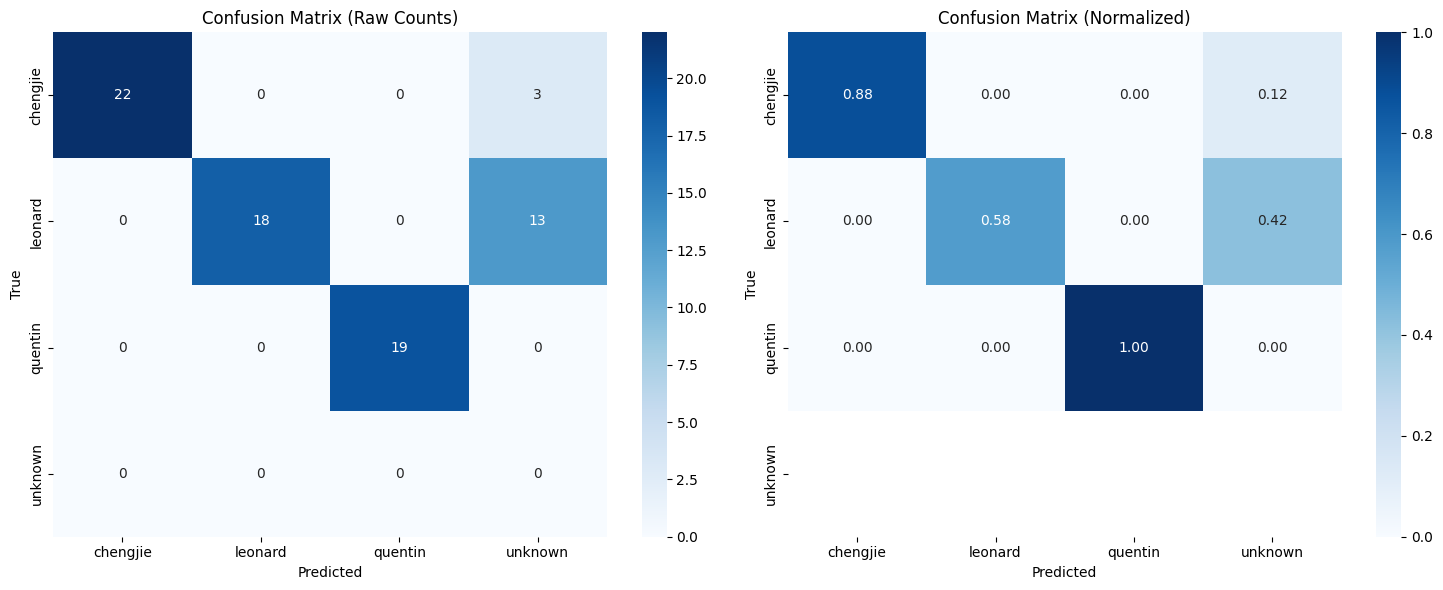


📊 Confusion Matrix (Raw Counts):
Labels: ['chengjie', 'leonard', 'quentin', 'unknown']
[[22  0  0  3]
 [ 0 18  0 13]
 [ 0  0 19  0]
 [ 0  0  0  0]]

📈 Classification Report:
              precision    recall  f1-score   support

    chengjie       1.00      0.88      0.94        25
     leonard       1.00      0.58      0.73        31
     quentin       1.00      1.00      1.00        19
     unknown       0.00      0.00      0.00         0

    accuracy                           0.79        75
   macro avg       0.75      0.62      0.67        75
weighted avg       1.00      0.79      0.87        75



In [8]:
# Create and display confusion matrix
if y_true and y_pred:
    # Calculate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Get unique labels
    labels = sorted(list(set(y_true + y_pred)))
    
    # Create figure with subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Raw confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=labels, yticklabels=labels, ax=ax1)
    ax1.set_title('Confusion Matrix (Raw Counts)')
    ax1.set_xlabel('Predicted')
    ax1.set_ylabel('True')
    
    # Plot 2: Normalized confusion matrix
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax2)
    ax2.set_title('Confusion Matrix (Normalized)')
    ax2.set_xlabel('Predicted')
    ax2.set_ylabel('True')
    
    plt.tight_layout()
    plt.show()
    
    # Print text version for reference
    print("\n📊 Confusion Matrix (Raw Counts):")
    print(f"Labels: {labels}")
    print(cm)
    
    print(f"\n📈 Classification Report:")
    print(classification_report(y_true, y_pred, zero_division=0))
else:
    print("❌ No data available for confusion matrix")

### Performance Analysis

Additional performance metrics and visualizations.

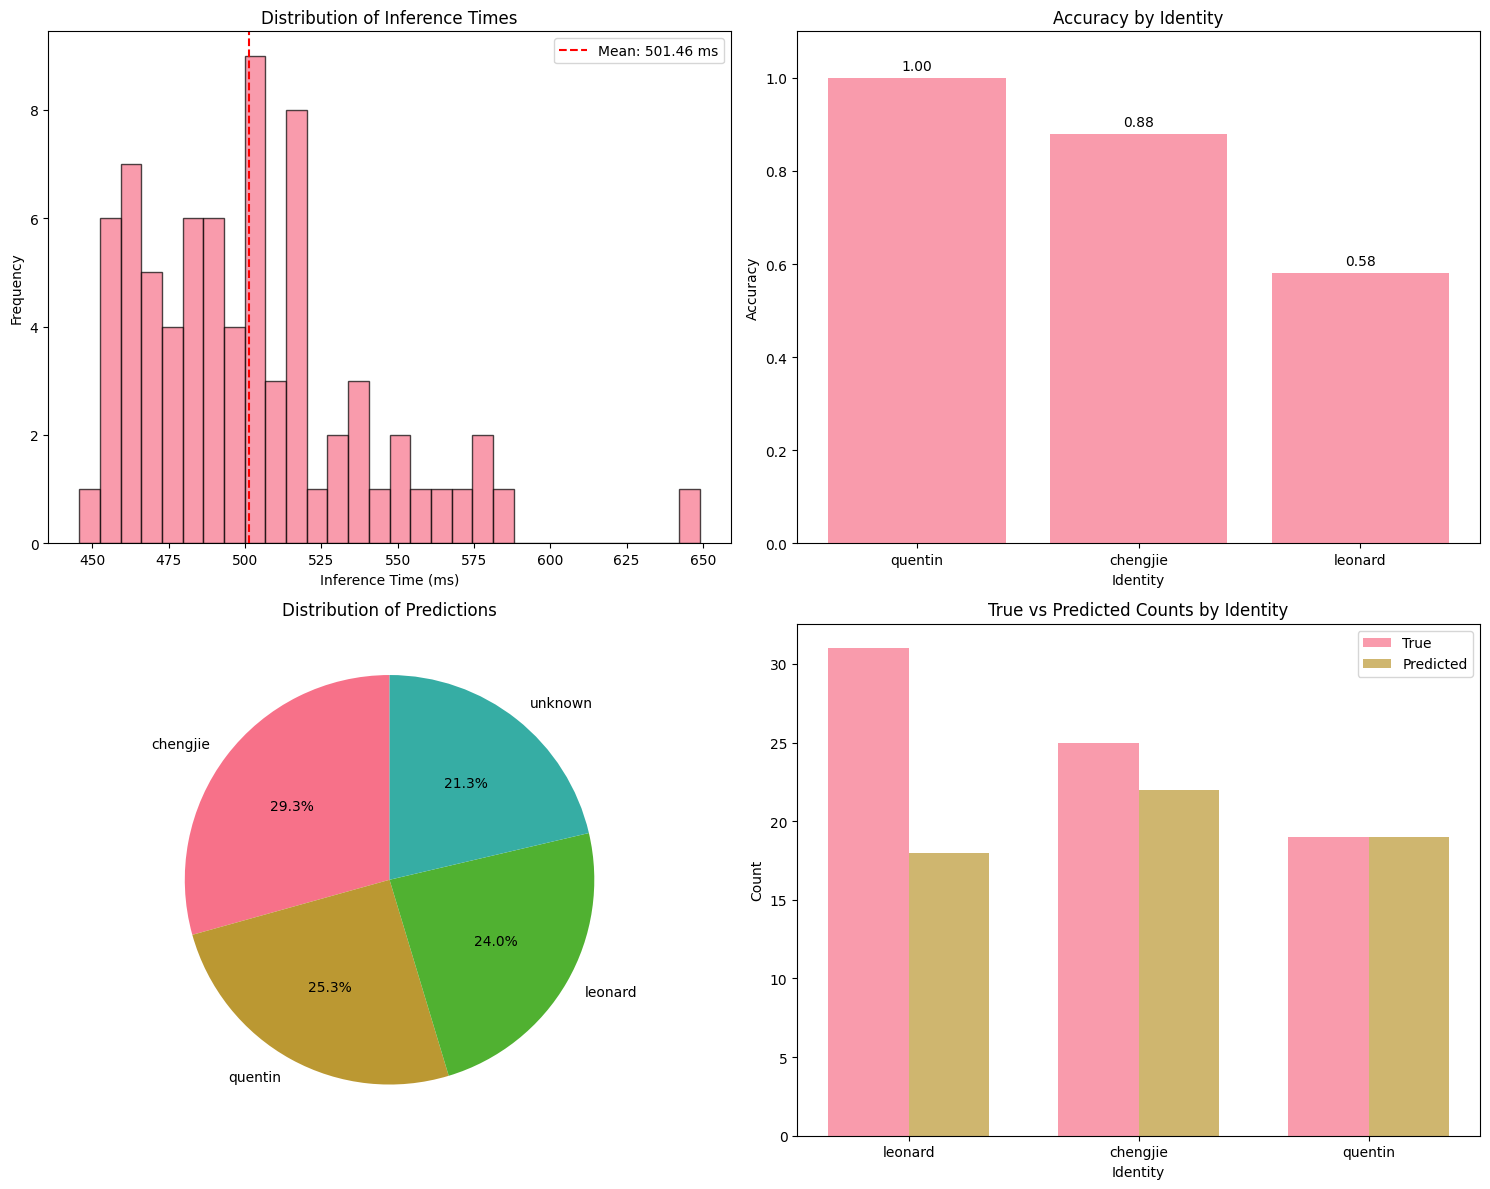


📈 Performance Summary by Identity:
  chengjie: 22/25 correct (88.00%)
  leonard: 18/31 correct (58.06%)
  quentin: 19/19 correct (100.00%)


In [9]:
# Performance Analysis Plots
if y_true and y_pred and times:
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Inference time distribution
    ax1.hist(np.array(times) * 1000, bins=30, edgecolor='black', alpha=0.7)
    ax1.set_xlabel('Inference Time (ms)')
    ax1.set_ylabel('Frequency')
    ax1.set_title('Distribution of Inference Times')
    ax1.axvline(avg_time, color='red', linestyle='--', label=f'Mean: {avg_time:.2f} ms')
    ax1.legend()
    
    # Plot 2: Accuracy by identity
    identity_accuracy = {}
    for true_id in set(y_true):
        true_mask = np.array(y_true) == true_id
        correct_mask = np.array(y_pred)[true_mask] == true_id
        identity_accuracy[true_id] = np.mean(correct_mask) if len(correct_mask) > 0 else 0
    
    identities = list(identity_accuracy.keys())
    accuracies = list(identity_accuracy.values())
    
    bars = ax2.bar(identities, accuracies, alpha=0.7)
    ax2.set_xlabel('Identity')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Accuracy by Identity')
    ax2.set_ylim(0, 1.1)
    
    # Add value labels on bars
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{acc:.2f}', ha='center', va='bottom')
    
    # Plot 3: Prediction distribution
    pred_counts = pd.Series(y_pred).value_counts()
    ax3.pie(pred_counts.values, labels=pred_counts.index, autopct='%1.1f%%', startangle=90)
    ax3.set_title('Distribution of Predictions')
    
    # Plot 4: True vs Predicted counts
    true_counts = pd.Series(y_true).value_counts()
    pred_counts_reindexed = pred_counts.reindex(true_counts.index, fill_value=0)
    
    x = np.arange(len(true_counts))
    width = 0.35
    
    ax4.bar(x - width/2, true_counts.values, width, label='True', alpha=0.7)
    ax4.bar(x + width/2, pred_counts_reindexed.values, width, label='Predicted', alpha=0.7)
    
    ax4.set_xlabel('Identity')
    ax4.set_ylabel('Count')
    ax4.set_title('True vs Predicted Counts by Identity')
    ax4.set_xticks(x)
    ax4.set_xticklabels(true_counts.index)
    ax4.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Summary statistics
    print(f"\n📈 Performance Summary by Identity:")
    for identity in sorted(identity_accuracy.keys()):
        total_images = sum(1 for t in y_true if t == identity)
        correct_predictions = sum(1 for t, p in zip(y_true, y_pred) if t == identity and p == identity)
        print(f"  {identity}: {correct_predictions}/{total_images} correct ({identity_accuracy[identity]:.2%})")
else:
    print("❌ No data available for performance analysis")

## Conclusion

This notebook provides a comprehensive testing framework for the DS50 face recognition system. The results show:

- **System Performance**: Overall accuracy and recognition capabilities
- **Visual Analysis**: Confusion matrix with both raw counts and normalized values  
- **Performance Metrics**: Inference time distribution and per-identity accuracy
- **Data Insights**: Distribution of predictions and comparison with ground truth

### Key Metrics Summary:
- Recognition threshold used for testing
- Average inference time per image
- Overall system accuracy
- Per-identity performance breakdown